# Image Super Resolution

This notebooks show an example of super resolution with cubic kernels

In [1]:
#%matplotlib ipympl
%cd ..
import torchtt as tntt
from src.qtt_interpolation.utils import *

/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
def skcubic_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1 , order = 1, boundary = 'lineare'):

    if not isinstance(f_boundary, tuple):
        f_boundary = [f_boundary, None]

    ni = len(mps.N)
    nc = fscale - ni 

    id0 = I_qtt(ni)
    sm10 = R_qtt( 2**ni -1, ni)
    sm20 = R_qtt( 2**ni -2, ni)
    smm10 = L_qtt( 1, ni)
    ones = tntt.ones([1]*ni)
    onesf = tntt.ones([2]*nc)
    delta = dmps(2**ni -1,ni)
    deltae = tntt.kron(delta,onesf)

    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2

        Mkct = Mkc.t()

        Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
        O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
        delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)
        delta2e = tntt.kron(delta2,onesf)
    elif order == 2:

        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

        Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
        O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
        delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)
        delta2e = tntt.kron(delta2,onesf)
    
        if boundary == 'lineare':
            Om10 = smm10 + 2*dmpo(0,0,ni) - dmpo(0,1,ni) 
            O20 = sm20 - dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) + 2*dmps(2**ni -1,ni)
        elif boundary == 'mirror':
            Om10 = smm10 +  dmpo(0,1,ni) 
            O20 = sm20 + dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) 
        elif boundary == 'clamped':
            Om10 = smm10 +  dmpo(0,0,ni) 
            O20 = sm20 
            delta2 = dmps(2**ni -2,ni) + dmps(2**ni -1,ni)

    if type(f_boundary[0]) is str:
        if f_boundary[0] == 'gaussian':
            scale = ni
            base_scaling = 2.0 ** (-4.0 / 3.0)
            r = 10
            f11 = 1 + (base_scaling**scale) * epsilon * np.random.randn()
            bx = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) ) * (1-delta) + f11*delta
            by = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1])) * (1-delta) + f11*delta
            corner = f11*delta
            corner2 = f11*delta2
        
        elif f_boundary[0] == 'zero':
            f11 = 0
            bx = tntt.zeros([2]*ni)
            by = tntt.zeros([2]*ni)
            corner = f11*delta
            corner2 = f11*delta2

    else:
        f11 = f_boundary[0][-1]
        bx = tntt.TT(tn.tensor(f_boundary[0],dtype=tn.float64),[2]*ni)
        by = tntt.TT( tn.tensor(f_boundary[1],dtype=tn.float64),[2]*ni)
        corner = f11*delta
        corner2 = f11*delta2

    mbx = zkron( delta , bx ).round(eps)
    mbx2 = zkron( delta2 , bx ).round(eps)

    pols = [tntt.TT(qtt_polynomial_cores(Mkct[i], nc)) for i in range(4)]
    polsx = [tntt.kron( ones, zkron(tntt.TT(qtt_polynomial_cores(Mkct[i], nc)) , onesf) ).round(eps) for i in range(4)]
    polsy = [tntt.kron( ones, zkron( onesf , tntt.TT( qtt_polynomial_cores(Mkct[i], nc)) ) ).round(eps) for i in range(4)]
    
    zones = zkron(onesf, onesf)
    mps = tntt.kron(mps, zones )
    mbx = tntt.kron(mbx, zones )
    mbx2 = tntt.kron(mbx2,zones )

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)

    f_kx =  (zkron(Om1,id) @ mps) *( polsx[0] ) + ( mps *  polsx[1] ) + ( zkron(sm1,id) @ mps + mbx) * (polsx[2]) +  ( zkron(O2,id) @ mps + mbx2) * ( polsx[3])
    f_kx = f_kx.round(eps)

    By = tntt.kron( ( Om10 @ by) , pols[0] ) + tntt.kron( by , pols[1] ) +  tntt.kron( sm10 @ by + corner, pols[2]) +  tntt.kron( O20 @ by + corner2 ,  pols[3])
    By = By.round(eps)
    mby = zkron( By , deltae )
    mby2 = zkron( By , delta2e )
    
    f_kcs = (zkron(id,Om1) @ f_kx) * ( polsy[0] ) + ( f_kx * polsy[1] ) + ( zkron(id,sm1) @ f_kx + mby) * (polsy[2]) + ( zkron(id,O2) @ f_kx + mby2) * (polsy[3]) 
    f_kcs = f_kcs.round(eps)

    return f_kcs

def morton_flatten(array):
    rows, cols = array.shape
    assert rows == cols and (rows & (rows - 1) == 0), "Array must be square with dimensions 2^n."

    def interleave_bits(x, y):
        z = 0
        for i in range(x.bit_length() | y.bit_length()):
            z |= ((y >> i) & 1) << (2 * i + 1)
            z |= ((x >> i) & 1) << (2 * i)
        return z

    flat = np.empty(rows * cols, dtype=array.dtype)
    for r in range(rows):
        for c in range(cols):
            idx = interleave_bits(r, c)
            flat[idx] = array[r, c]

    return flat


def downsample_area_1d(v, new_len):
    old_len = v.shape[0]
    factor  = old_len // new_len
    # reshape into (new_len, factor)
    return v.reshape(new_len, factor).mean(axis=1)




*mountains* Photo by <a href="https://unsplash.com/@devonshiremedia?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Craig Tidball</a> on <a href="https://unsplash.com/photos/grayscale-photo-of-person-riding-on-boat-on-lake-near-rocky-mountain-nLu8yaN7YY8?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Unsplash</a>

*mountains2* Photo by <a href="https://unsplash.com/@ballaschottner?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Bence Balla-Schottner</a> on <a href="https://unsplash.com/photos/grayscale-photography-of-cliff-GofPJyMdNvk?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Unsplash</a>

*piramids* Photo by <a href="https://unsplash.com/@jeremylishner?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Jeremy Lishner</a> on <a href="https://unsplash.com/photos/gray-concrete-temple-qQkhVM9bp10?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Unsplash</a>
      
      

In [4]:
# 5. Upscale to 1024x1024 using cubic interpolation
from scipy.ndimage import zoom
# Load Image
import urllib.request
import os
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# 1. Download Lena if it's not already in the current directory
local_filename = "./examples/images/piramids.jpg"

# 2. Read the image in color
image_color = cv2.imread(local_filename, cv2.IMREAD_COLOR)
# Downscale to 2048x2048 as the initial resolution
image_color = cv2.resize(image_color, (2048, 2048), interpolation=cv2.INTER_NEAREST)
height, width, channels = image_color.shape  # shape gives (height, width, channels)

# 4. Print the resolution
print(f"Initial Resolution: {width}x{height} (Width x Height)")

# 3. Convert to grayscale (black-and-white)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)
image_gray = image_gray.astype(np.uint8) 
# 4. Resize to 128x128 (if needed) using INTER_AREA for initial sizing
id = 7
image_gray_128 = cv2.resize(image_gray, (2**id, 2**id), interpolation=cv2.INTER_AREA)
row_area = downsample_area_1d(image_gray[-1,:], 2**id)
col_area = downsample_area_1d(image_gray[:,-1], 2**id)


row = image_gray[-1, :]        # shape (2048,)
col = image_gray[:,  -1]       # shape (2048,)
factor = 2048 // 2**id           # =16
#image_gray_128 = image_gray[::factor, ::factor]
row_nn = row[::factor]         # shape (128,)
col_nn = col[::factor]         # shape (128,)

Initial Resolution: 2048x2048 (Width x Height)


In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

z0 = morton_flatten(image_gray_128)
mpz0 = tntt.TT(tn.tensor(z0,dtype=tn.float64),[4]*id,eps=1e-15)
fb = (col_area,row_area)
# Clear the lists if needed
fscale = []
comp = []
L2 = []

# First entry already computed previously using mpz0
entries = sum([tn.numel(c) for c in mpz0.cores])
compression = entries / np.prod(np.array(mpz0.N, dtype=np.float64))
fscale.append(id)
comp.append(compression)
L2.append(0.0)

# Run iterations until d = 14, but only for d <= 11 do plots and L2 norm calculation.
for exdim in range(1, 21-id):
    d = id + exdim
    mpZ = skcubic_i(mpz0, d, f_boundary=fb, eps=1e-14, epsilon=0.1, order=1)
    entries = sum([tn.numel(c) for c in mpZ.cores])
    fscale.append(d)
    compression = entries / np.prod(np.array(mpZ.N, dtype=np.float64))
    comp.append(f"{compression:.1e}")
    
    # Only compute and show plots and L2 norm if the resolution is at most the original image size (2**11 = 2048)
    if d <= 11:
        restored_img = mpZ.full().flatten()
        restored_img = z_order_to_normal_torch(restored_img, 2**d, 2**d).t().cpu().numpy()

        original_down = cv2.resize(image_gray, (2**d, 2**d), interpolation=cv2.INTER_AREA)
        factor = 2**(11 - d)    # if original is 2**11
        #original_down = image_gray[::factor, ::factor]


        L2_score = np.linalg.norm(restored_img.astype(np.float64) - original_down.astype(np.float64))/np.linalg.norm(original_down.astype(np.float64))
        L2.append(L2_score)

        ''' 
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        axs[0].imshow(original_down, cmap='gray')
        axs[0].set_title(f'Original {2**d}x{2**d}')
        axs[0].axis('off')
        axs[1].imshow(restored_img, cmap='gray')
        axs[1].set_title(f'Restored {2**d}x{2**d}\nL2: {L2_score:.4e}')
        axs[1].axis('off')
        plt.tight_layout()
        plt.show()
        ''' 
    # Update dataframe for each iteration (if needed)
    df = pd.DataFrame({
        'Dimension': fscale,
        'Compression': [float(c) for c in comp]
    })


In [6]:
d = 11
mpZ = skcubic_i(mpz0, d, f_boundary=fb, eps=1e-14, epsilon=0.1, order=1)

restored_img_d11 = mpZ.full().flatten()
restored_img_d11 = z_order_to_normal_torch(restored_img_d11, 2**d, 2**d).t().cpu().numpy()




### Metrics only

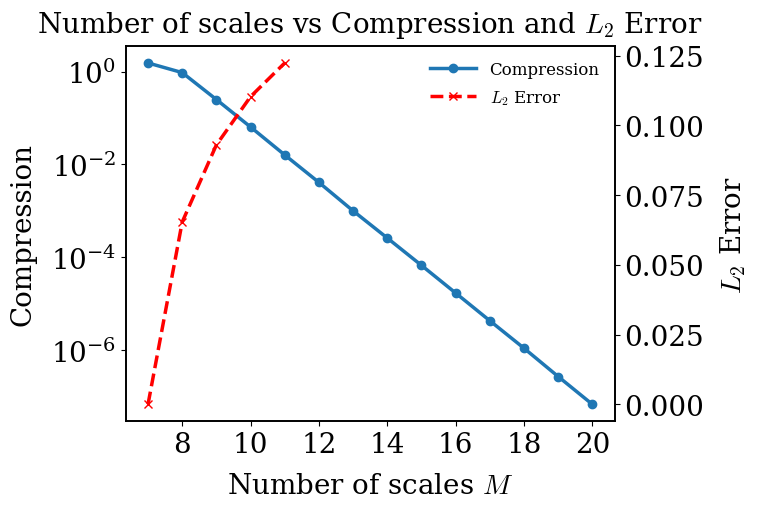

In [9]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# --- Styling (match your formatted figures) ---
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 12,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams['axes.grid'] = False

# --- Figure & primary axis ---
fig, ax1 = plt.subplots(figsize=(7.5, 5.2))

# Compression (left y, log)
ax1.plot(
    df['Dimension'], df['Compression'],
    marker='o', linestyle='-',
    label='Compression'
)
ax1.set_xlabel('Number of scales $M$', labelpad=10)
ax1.set_ylabel('Compression', labelpad=10)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# --- Twin axis for L2 error ---
ax2 = ax1.twinx()
ax2.plot(
    df['Dimension'].iloc[:len(L2)], L2,
    marker='x', linestyle='--', color='red',
    label=r'$L_2$ Error'
)
ax2.set_ylabel(r'$L_2$ Error', labelpad=10)

# --- Title ---
ax1.set_title('Number of scales vs Compression and $L_2$ Error', pad=10)

# --- Legend (keep inside) ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper right', frameon=False, handlelength=2.8, labelspacing=0.6
)

# --- Thicken spines + enforce tick label sizes ---
for ax in (ax1, ax2):
    for sp in ax.spines.values():
        sp.set_linewidth(1.2)
    ax.tick_params(axis='both', which='major', labelsize=20)

fig.tight_layout()

# --- Save ---
out_dir = './examples/figs'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'scales_vs_compression_L2error.pdf'),
            format='pdf', bbox_inches='tight', facecolor='white')

plt.show()


### comparisson 

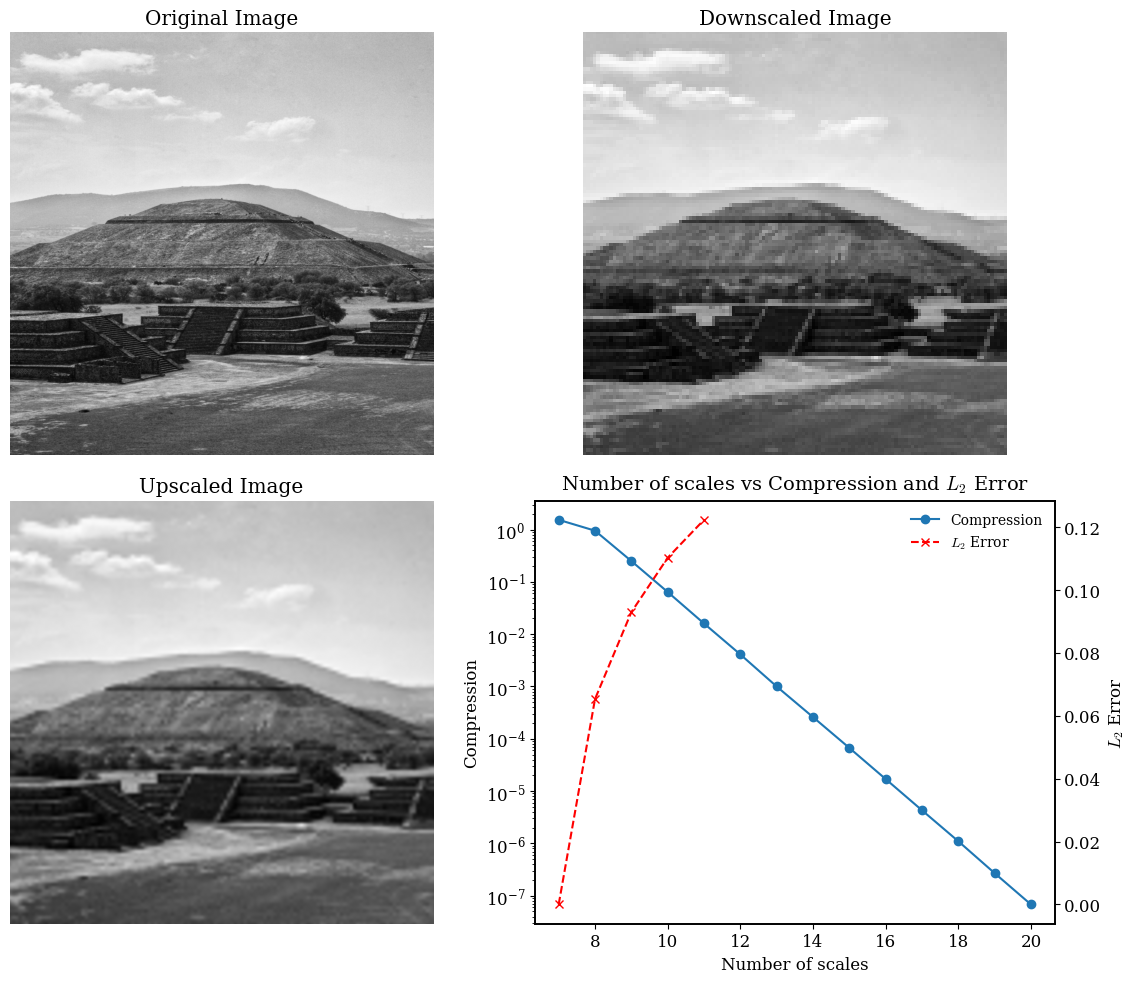

In [14]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterSciNotation

# Assume image_gray, image_gray_128, restored_img_d12, df, and L2 are already defined

# 1) Serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Create 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 3) Plot the images
axs[0, 0].imshow(image_gray, cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

axs[0, 1].imshow(image_gray_128, cmap='gray')
axs[0, 1].set_title('Downscaled Image')
axs[0, 1].axis('off')

axs[1, 0].imshow(restored_img_d11, cmap='gray')
axs[1, 0].set_title('Upscaled Image')
axs[1, 0].axis('off')

# 4) Metrics plot on lower right
ax1 = axs[1, 1]
ax1.plot(df['Dimension'], df['Compression'], marker='o', linestyle='-', label='Compression')
ax1.set_xlabel('Number of scales', fontsize=12)
ax1.set_ylabel('Compression', fontsize=12)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())

ax2 = ax1.twinx()
ax2.plot(df['Dimension'].iloc[:len(L2)], L2, marker='x', linestyle='--', color='red', label=r'$L_2$ Error')
ax2.set_ylabel(r'$L_2$ Error', fontsize=12)

ax1.set_title('Number of scales vs Compression and $L_2$ Error', pad=8, fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False, fontsize=10)

# 5) Thicken spines
for spine_ax in (ax1, ax2):
    for spine in spine_ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()

# 6) Save figure
out_dir = './examples/figs'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'comparison_and_metrics.pdf'),
            format='pdf',
            bbox_inches='tight')

plt.show()


### Save plots

In [17]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterSciNotation

# Ensure output directory exists
out_dir = './examples/figs'
os.makedirs(out_dir, exist_ok=True)

# 1) Serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Original Image (no title)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image_gray, cmap='gray')
ax.axis('off')
fig.savefig(os.path.join(out_dir, 'original.pdf'),
            format='pdf', bbox_inches='tight')
plt.close(fig)

# 3) Downscaled Image (no title)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image_gray_128, cmap='gray')
ax.axis('off')
fig.savefig(os.path.join(out_dir, 'downscaled.pdf'),
            format='pdf', bbox_inches='tight')
plt.close(fig)

# 4) Upscaled Image (no title)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(restored_img_d11, cmap='gray')
ax.axis('off')
fig.savefig(os.path.join(out_dir, 'upscaled.pdf'),
            format='pdf', bbox_inches='tight')
plt.close(fig)

# 5) Metrics Plot (with title and labels as before)
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(df['Dimension'], df['Compression'], marker='o', linestyle='-', label='Compression')
ax1.set_xlabel('Number of scales', fontsize=12)
ax1.set_ylabel('Compression', fontsize=12)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())

ax2 = ax1.twinx()
ax2.plot(df['Dimension'].iloc[:len(L2)], L2, marker='x', linestyle='--', color='red', label=r'$L_2$ Error')
ax2.set_ylabel(r'$L_2$ Error', fontsize=12)

ax1.set_title('Scales vs Compression & $L_2$ Error', pad=8, fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right',
           frameon=False, fontsize=10)

for spine in ax1.spines.values():
    spine.set_linewidth(1.2)
for spine in ax2.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, 'metrics.pdf'),
            format='pdf', bbox_inches='tight')
plt.close(fig)
